### Inspecting the Lists

In [ ]:
import pandas as pd
import pickle

# Load the dataset
df = pd.read_csv("/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_master_matrix_shifted.csv", sep='\t', index_col=0)

with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl", "rb") as f:
    housekeeping_genes = pickle.load(f)

hk_genes = [
  "YFL039C",  # ACT1 (Actin)
  "YGR192C",  # TDH3 (Glyceraldehyde-3-phosphate dehydrogenase)
  "YCR012W",  # PGK1 (Phosphoglycerate kinase)
  "YHR174W",  # ENO2 (Enolase 2)
  "YGR240C",  # PFK1 (Phosphofructokinase alpha)
  "YGL253W",  # HXK2 (Hexokinase 2)
  "YGL008C",  # PMA1 (Plasma membrane H+-ATPase)
  "YKL114C",  # APN1 (DNA repair)
  "YBR160W",  # CDC28 (Cyclin-dependent kinase)
  "YDR362C",  # TFC1 (Transcription factor component)
  "YNL102W",  # POL1 (DNA polymerase alpha)
  "YDR050C",  # TPI1 (Triose phosphate isomerase)
  "YLR224W",  # UBC6 (Ubiquitin-conjugating enzyme)
  "YPL237W",  # SUI1 (Translation initiation factor)
  "YDR296W",  # MHR1 (Homologous recombination)
  "YML099C",  # ARG81 (Transcription factor)
  "YBR118W",  # TEF2 (Translation elongation factor EF-1 alpha)
  "YDR224C",  # HTB1 (Histone H2B)
  "YBR010W",  # GRX7 (Glutaredoxin)
  "YPL151C",  # PRP46 (Spliceosome component)
  "YNCL0016C",  # 18S rRNA
  "YDR261C",  # EXG1 (Exo-1,3-beta-glucanase)
  "YGL195W",  # GDH1 (Glutamate dehydrogenase)
  "YDR155C",  # CPR1 (Cyclophilin A-type PPIase)
  "YHR085W"   # STE11 (MAPKKK, involved in signal transduction)
  ]

for hk_id in hk_genes:
  if hk_id not in df.index:
    print(f"Missing HK {hk_id} in the dataset")

with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl", "rb") as f:
    tf_genes = pickle.load(f)

for tf_id in tf_genes:
  if tf_id not in df.index:
    print(f"Missing TF {tf_id} in the dataset")


### HS vs TF NaN Distribution

In [ ]:
import pandas as pd
import pickle

# Load the dataset
df = pd.read_csv("/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_master_matrix_dual.csv", sep='\t', index_col=0)

# Load housekeeping gene IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl", "rb") as f:
    housekeeping_genes = pickle.load(f)

# Load transcription factor IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl", "rb") as f:
    transcription_factors = pickle.load(f)

# Ensure the genes in hk_genes and tf_genes are present in the dataset index
housekeeping_genes = [gene for gene in housekeeping_genes if gene in df.index]
transcription_factors = [gene for gene in transcription_factors if gene in df.index]

# Compute the number of missing values (NaNs) for each gene in each group
hk_genes_nans = df.loc[housekeeping_genes].isna().sum(axis=1)  # Count NaNs per housekeeping gene
tf_genes_nans = df.loc[transcription_factors].isna().sum(axis=1)  # Count NaNs per transcription factor gene

# Calculate the average number of NaNs per gene in each group
avg_nans_hk = hk_genes_nans.mean()  # Average NaNs per housekeeping gene
avg_nans_tf = tf_genes_nans.mean()  # Average NaNs per transcription factor gene

# Calculate the total number of NaNs in each group
total_nans_hk = hk_genes_nans.sum()  # Total NaNs for housekeeping genes
total_nans_tf = tf_genes_nans.sum()  # Total NaNs for transcription factor genes

# Print the results
print(f"Average number of missing values (NaNs) per housekeeping gene: {avg_nans_hk}")
print(f"Average number of missing values (NaNs) per transcription factor gene: {avg_nans_tf}")

# Print total number of NaNs in each group
print(f"Total number of missing values (NaNs) in housekeeping genes: {total_nans_hk}")
print(f"Total number of missing values (NaNs) in transcription factor genes: {total_nans_tf}")

#### Confirming the Intuition

In [ ]:
import pickle
import pandas as pd

# Load the full dataset (log2 transformed or processed values)
file_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_master_matrix_dual.csv"
df = pd.read_csv(file_path, sep='\t', index_col=0)

# Load housekeeping genes
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl", "rb") as f:
    housekeeping_genes = pickle.load(f)

# Load transcription factor IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl", "rb") as f:
    transcription_factors = pickle.load(f)

# Keep only those genes present in df
housekeeping_genes = [gene for gene in housekeeping_genes if gene in df.index]
transcription_factors = [gene for gene in transcription_factors if gene in df.index]

# Compute the overall mean expression per gene (averaged across all conditions)
gene_means = df.mean(axis=1)

# Compute the overall mean expression for each group
housekeeping_mean = gene_means.loc[housekeeping_genes].mean()
tf_mean = gene_means.loc[transcription_factors].mean()

print(f"Housekeeping genes mean expression: {housekeeping_mean}")
print(f"Transcription factors mean expression: {tf_mean}")

### Median Check HS vs TF

#### Plot

In [ ]:
import pickle 

with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_median_dict_dual_abs.pkl", "rb") as f:
    normalization_factors = pickle.load(f)

print(normalization_factors)
print(abs(normalization_factors['Q0010']-normalization_factors['Q0017']))

In [ ]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the full dataset (log2 transformed or processed values)
file_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_master_matrix_dual.csv"
df = pd.read_csv(file_path, sep='\t', index_col=0)

# Load housekeeping gene IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl", "rb") as f:
    housekeeping_genes = pickle.load(f)

# Load transcription factor IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl", "rb") as f:
    transcription_factors = pickle.load(f)

housekeeping_genes = [gene for gene in housekeeping_genes if gene in df.index]
transcription_factors = [gene for gene in transcription_factors if gene in df.index]

# Extract expression values for each group (all genes, housekeeping, and transcription factors)
all_values = df.values.flatten()  # Flatten to get a 1D array of all values
housekeeping_values = df.loc[housekeeping_genes].values.flatten()  # Values for housekeeping genes
tf_values = df.loc[transcription_factors].values.flatten()  # Values for transcription factors

# Create a dataframe for seaborn (mean of each group)
df_box = pd.DataFrame({
    "Normalization Factor": [
        np.mean(all_values), 
        np.mean(housekeeping_values), 
        np.mean(tf_values)
    ],
    "Category": ["All genes", "Housekeeping", "Transcription factors"]
})

# Plot barplot
plt.figure(figsize=(5, 4))
sns.barplot(x="Category", y="Normalization Factor", data=df_box, palette=["#4878d0", "#e07b39", "#6aaf48"])

plt.xlabel("")
plt.ylabel("Average Expression")
plt.title("Average Normalization Factors (Full Dataset)")
plt.xticks(rotation=20)

plt.show()

# Print the average normalization factors
print([np.mean(all_values), np.mean(housekeeping_values), np.mean(tf_values)])


In [ ]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load normalization factors (dictionary: {gene_id: normalization_factor})
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_median_dict_dual_abs.pkl", "rb") as f:
    normalization_factors = pickle.load(f)

# Load housekeeping gene IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl", "rb") as f:
    housekeeping_genes = pickle.load(f)

# Load transcription factor IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl", "rb") as f:
    transcription_factors = pickle.load(f)

# Extract normalization values for each group
all_values = list(normalization_factors.values())
housekeeping_values = [normalization_factors[gene] for gene in housekeeping_genes if gene in normalization_factors]
tf_values = [normalization_factors[gene] for gene in transcription_factors if gene in normalization_factors]

# Create a dataframe for seaborn
df = pd.DataFrame({
    "Normalization Factor": [np.mean(all_values), np.mean(housekeeping_values), np.mean(tf_values)],
    "Category": ["All genes", "Housekeeping", "Transcription factors"]
})

# Plot barplot
plt.figure(figsize=(5, 4))
sns.barplot(x="Category", y="Normalization Factor", data=df, palette=["#4878d0", "#e07b39", "#6aaf48"])

plt.xlabel("")
plt.ylabel("Average Non-zero Median Expression")
plt.title("Average Normalization Factors")
plt.xticks(rotation=20)

plt.show()

print([np.mean(all_values), np.mean(housekeeping_values), np.mean(tf_values)])

#### Statistical Significance

In [ ]:
import random
import matplotlib.pyplot as plt
import pickle
import numpy as np

# Load normalization factors (dictionary: {gene_id: normalization_factor})
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_median_dict_dual_exp.pkl", "rb") as f:
    gene_median_nonzero_dict = pickle.load(f)

# Load housekeeping gene IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl", "rb") as f:
    housekeeping_genes = pickle.load(f)

# Filter housekeeping genes that exist in the normalization factors dictionary
hk_values = [gene_median_nonzero_dict[gene] for gene in housekeeping_genes if gene in gene_median_nonzero_dict]
n = len(hk_values)

if n == 0:
    print("No housekeeping gene values found in the normalization factors dictionary.")
else:
    # Compute the observed mean for housekeeping genes
    observed_mean = np.mean(hk_values)
    
    # Set number of permutations
    mcmax = 9999
    mean_array = np.zeros(mcmax)
    all_genes = list(gene_median_nonzero_dict.keys())

    # Perform sampling and compute the mean for each random sample
    for i in range(mcmax):
        sampled_keys = random.sample(all_genes, n)
        sampled_values = [gene_median_nonzero_dict[k] for k in sampled_keys]
        mean_array[i] = np.mean(sampled_values)

    # Calculate the p-value (non-parametric)
    p_value = (np.sum(mean_array >= observed_mean) + 1) / (mcmax + 1)
    print(f"Observed mean for housekeeping genes: {observed_mean}")
    print(f"P-value: {p_value}")

    # Plot histogram of the permutation distribution and mark the observed mean
    plt.figure(figsize=(10, 6))
    plt.hist(mean_array, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(observed_mean, color='red', linestyle='dashed', linewidth=2,
                label=f'Observed Housekeeping Mean: {observed_mean:.3f}')
    plt.title('Empirical Null Distribution of Mean Normalization Factors\nvia Random Sampling', fontsize=14)
    plt.xlabel('Mean Normalization Factor', fontsize=12)
    plt.ylabel('Frequency (Number of Samples)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.show()

In [ ]:
import random
import matplotlib.pyplot as plt
import pickle
import numpy as np

# Load normalization factors (dictionary: {gene_id: normalization_factor})
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_median_dict_quantile.pkl", "rb") as f:
    gene_median_nonzero_dict = pickle.load(f)

# Load transcription factor (TF) gene IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl", "rb") as f:
    tf_genes = pickle.load(f)

# Filter TF genes that exist in the normalization factors dictionary
tf_values = [gene_median_nonzero_dict[gene] for gene in tf_genes if gene in gene_median_nonzero_dict]
n = len(tf_values)

if n == 0:
    print("No transcription factor values found in the normalization factors dictionary.")
else:
    # Compute the observed mean for transcription factors
    observed_mean = np.mean(tf_values)
    
    # Set number of permutations
    mcmax = 9999
    mean_array = np.zeros(mcmax)
    all_genes = list(gene_median_nonzero_dict.keys())

    # Perform sampling and compute the mean for each random sample
    for i in range(mcmax):
        sampled_keys = random.sample(all_genes, n)
        sampled_values = [gene_median_nonzero_dict[k] for k in sampled_keys]
        mean_array[i] = np.mean(sampled_values)

    # Calculate the p-value (non-parametric)
    p_value = (np.sum(mean_array >= observed_mean) + 1) / (mcmax + 1)
    print(f"Observed mean for transcription factors: {observed_mean}")
    print(f"P-value: {p_value}")

    # Plot histogram of the permutation distribution and mark the observed mean
    plt.figure(figsize=(10, 6))
    plt.hist(mean_array, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(observed_mean, color='red', linestyle='dashed', linewidth=2,
                label=f'Observed TF Mean: {observed_mean:.3f}')
    plt.title('Empirical Null Distribution of Mean Normalization Factors\nvia Random Sampling for Transcription Factors', fontsize=14)
    plt.xlabel('Mean Normalization Factor', fontsize=12)
    plt.ylabel('Frequency (Number of Samples)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.show()

In [ ]:
import random
import matplotlib.pyplot as plt
import pickle
import numpy as np

# Load normalization factors (dictionary: {gene_id: normalization_factor})
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_median_dict_quantile.pkl", "rb") as f:
    gene_median_nonzero_dict = pickle.load(f)

# Load housekeeping gene IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl", "rb") as f:
    housekeeping_genes = pickle.load(f)

# Load transcription factor (TF) gene IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl", "rb") as f:
    tf_genes = pickle.load(f)

# Filter genes that exist in the normalization factors dictionary
hk_values = [gene_median_nonzero_dict[gene] for gene in housekeeping_genes if gene in gene_median_nonzero_dict]
tf_values = [gene_median_nonzero_dict[gene] for gene in tf_genes if gene in gene_median_nonzero_dict]

n_hk = len(hk_values)
n_tf = len(tf_values)

if n_hk == 0 or n_tf == 0:
    print("No valid housekeeping or transcription factor gene values found in the normalization factors dictionary.")
else:
    # Compute observed mean difference
    observed_diff = np.mean(hk_values) - np.mean(tf_values)
    
    # Set number of permutations
    mcmax = 9999
    diff_array = np.zeros(mcmax)
    combined_values = hk_values + tf_values

    # Perform permutation test
    for i in range(mcmax):
        random.shuffle(combined_values)
        perm_hk = combined_values[:n_hk]
        perm_tf = combined_values[n_hk:]
        diff_array[i] = np.mean(perm_hk) - np.mean(perm_tf)

    # Calculate p-value (two-tailed)
    p_value = (np.sum(np.abs(diff_array) >= np.abs(observed_diff)) + 1) / (mcmax + 1)
    print(f"Observed mean difference (HK - TF): {observed_diff}")
    print(f"P-value: {p_value}")

    # Plot histogram of the permutation distribution and mark the observed difference
    plt.figure(figsize=(10, 6))
    plt.hist(diff_array, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2,
                label=f'Observed Difference: {observed_diff:.3f}')
    plt.title('Permutation Test: Housekeeping vs Transcription Factors', fontsize=14)
    plt.xlabel('Mean Normalization Factor Difference (HK - TF)', fontsize=12)
    plt.ylabel('Frequency (Number of Samples)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.show()


In [ ]:
from scipy.stats import mannwhitneyu

# Load normalization factors (dictionary: {gene_id: normalization_factor})
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_median_dict_quantile.pkl", "rb") as f:
    gene_median_nonzero_dict = pickle.load(f)

# Load housekeeping gene IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl", "rb") as f:
    housekeeping_genes = pickle.load(f)

# Load transcription factor (TF) gene IDs
with open("/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl", "rb") as f:
    tf_genes = pickle.load(f)

# Filter genes that exist in the normalization factors dictionary
hk_values = [gene_median_nonzero_dict[gene] for gene in housekeeping_genes if gene in gene_median_nonzero_dict]
tf_values = [gene_median_nonzero_dict[gene] for gene in tf_genes if gene in gene_median_nonzero_dict]

# Perform Wilcoxon rank-sum test (Mann-Whitney U test)
stat, p_value = mannwhitneyu(hk_values, tf_values, alternative='two-sided')

print(f"Mann-Whitney U Test Statistic: {stat}")
print(f"P-value: {p_value}")

### Distribution of Expression for Housekeeping

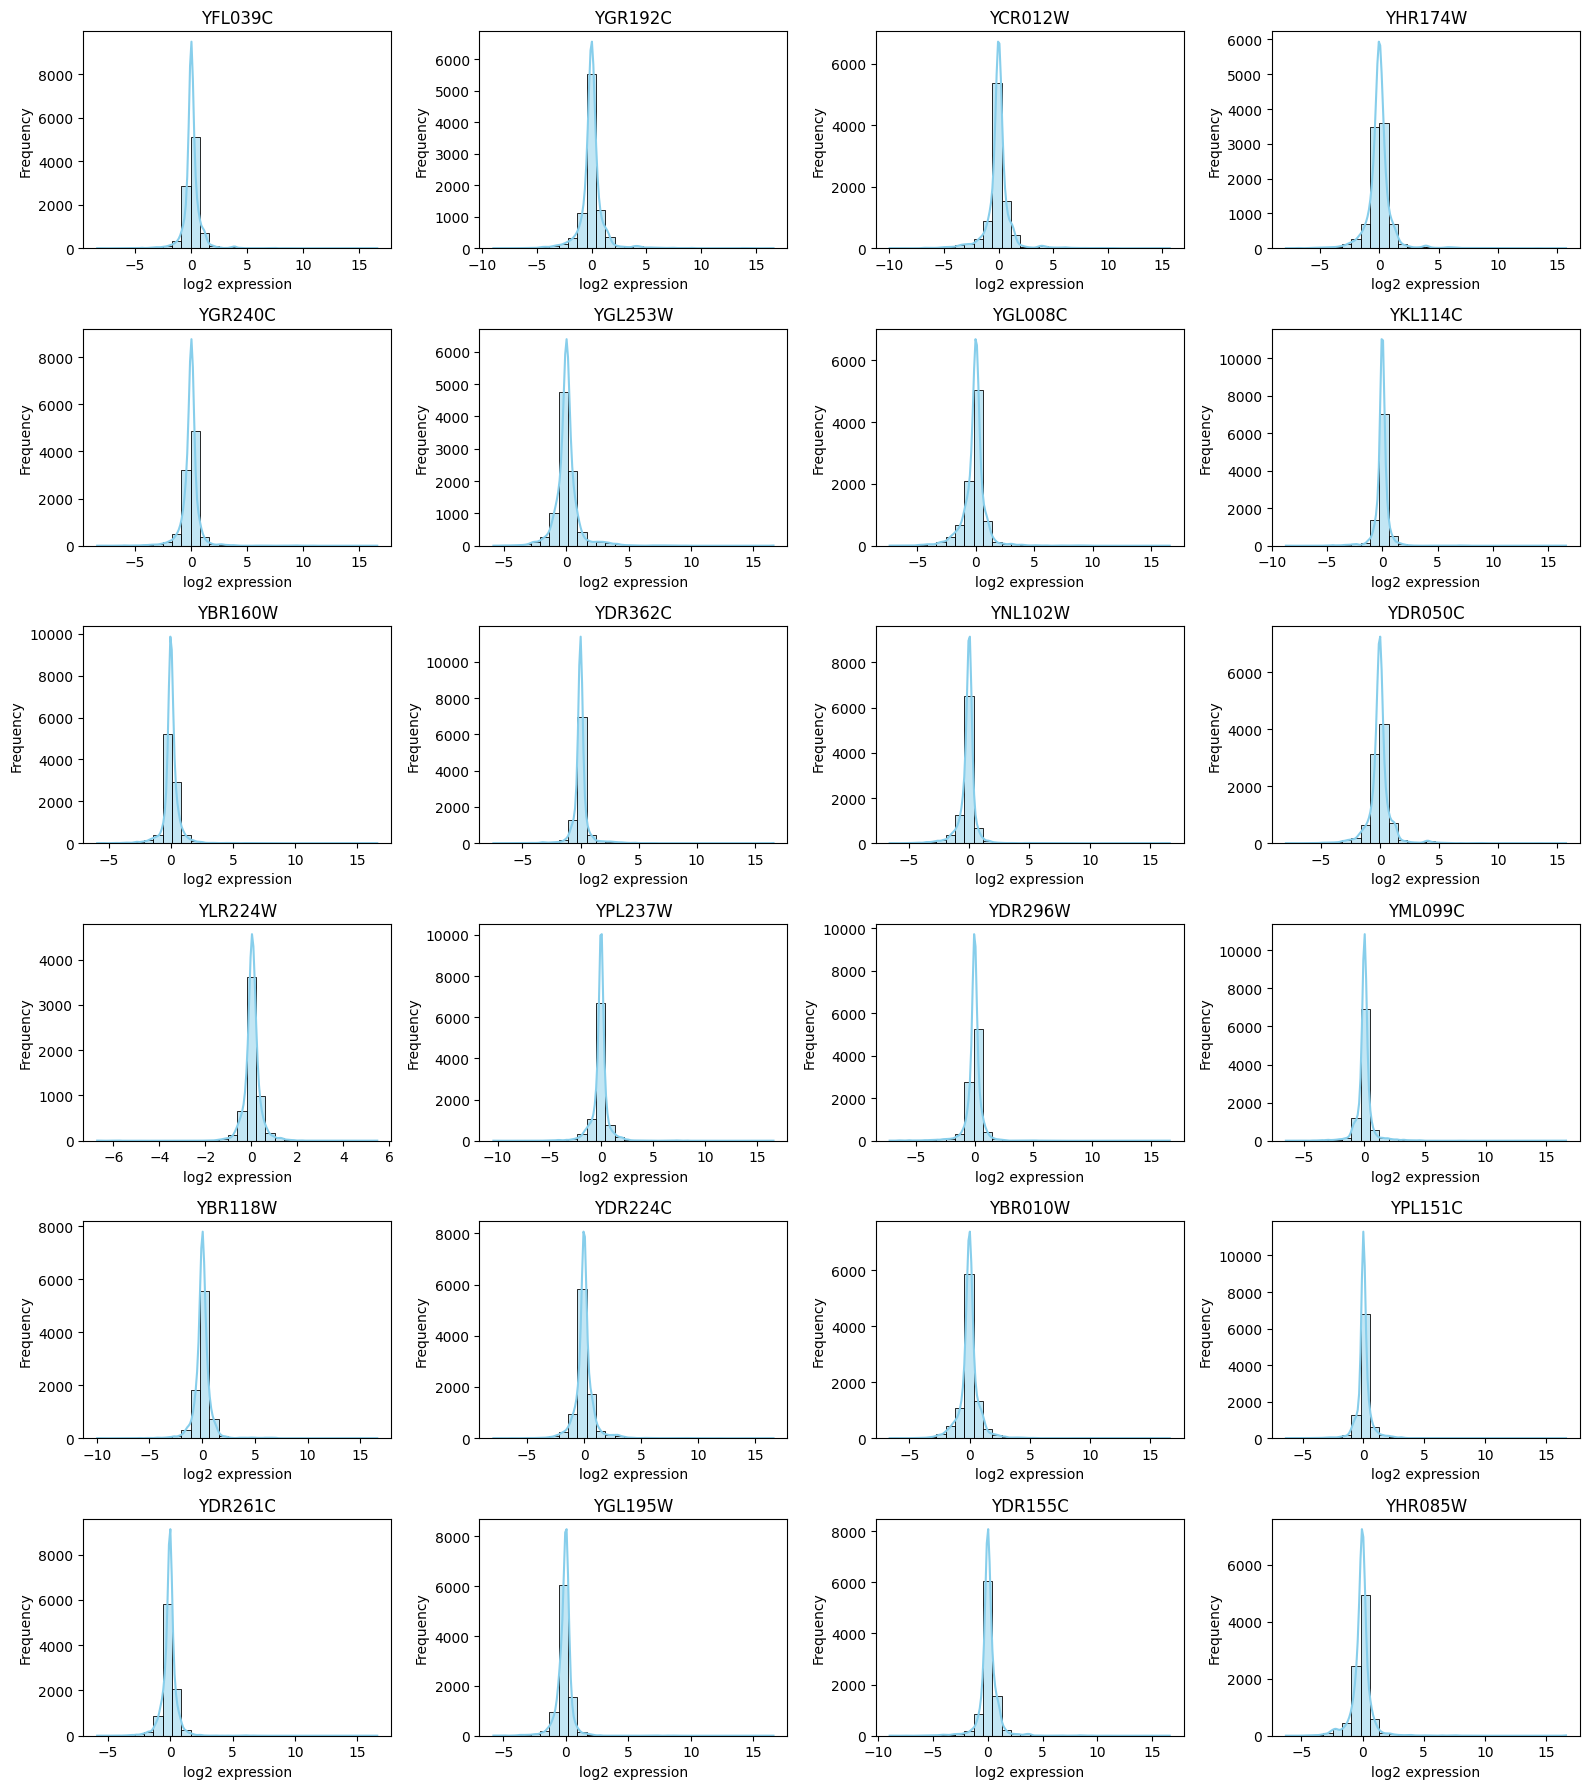

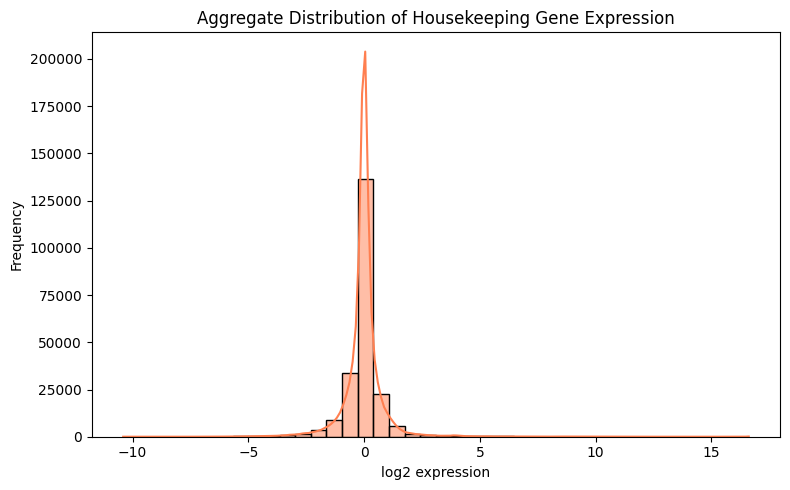

In [17]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

# Paths
data_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_master_matrix_dual.csv"
hk_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl"
output_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/hs_tf_study"
stats_output_path = os.path.join(output_dir, "stats_hk.txt")
histogram_path = os.path.join(output_dir, "housekeeping_expression_histograms.svg")
aggregate_path = os.path.join(output_dir, "housekeeping_expression_aggregate.svg")

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load dataset
df = pd.read_csv(data_path, sep='\t', index_col=0)

# Load housekeeping genes
with open(hk_pickle_path, "rb") as f:
    housekeeping_genes = pickle.load(f)

# Filter genes that are actually in the dataset
housekeeping_genes = [gene for gene in housekeeping_genes if gene in df.index]

# Stats file handle
with open(stats_output_path, "w") as stats_file:

    # --- Individual stats and histograms ---
    num_genes = len(housekeeping_genes)
    cols = 4
    rows = math.ceil(num_genes / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = axes.flatten()

    all_values = []

    for i, gene in enumerate(housekeeping_genes):
        values = df.loc[gene].dropna()
        all_values.extend(values.tolist())

        mean = np.mean(values)
        median = np.median(values)
        std = np.std(values)

        stats_file.write(f"\nGene: {gene}\n")
        stats_file.write(f"  Mean: {mean:.4f}\n")
        stats_file.write(f"  Median: {median:.4f}\n")
        stats_file.write(f"  Std Dev: {std:.4f}\n")
        stats_file.write(f"  Min: {np.min(values):.4f}\n")
        stats_file.write(f"  Max: {np.max(values):.4f}\n")
        stats_file.write(f"  Non-NaN values: {len(values)}\n")

        sns.histplot(values, bins=30, kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(gene)
        axes[i].set_xlabel("log2 expression")
        axes[i].set_ylabel("Frequency")

    # Hide extra subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(histogram_path, format='svg', dpi=500)
    plt.show()

    # --- Aggregate stats ---
    all_values = np.array(all_values)
    stats_file.write("\n=== Aggregate statistics for all housekeeping genes ===\n")
    stats_file.write(f"  Mean: {np.mean(all_values):.4f}\n")
    stats_file.write(f"  Median: {np.median(all_values):.4f}\n")
    stats_file.write(f"  Std Dev: {np.std(all_values):.4f}\n")
    stats_file.write(f"  Min: {np.min(all_values):.4f}\n")
    stats_file.write(f"  Max: {np.max(all_values):.4f}\n")
    stats_file.write(f"  Total values: {len(all_values)}\n")

# Plot aggregate histogram
plt.figure(figsize=(8, 5))
sns.histplot(all_values, bins=40, kde=True, color='coral')
plt.title("Aggregate Distribution of Housekeeping Gene Expression")
plt.xlabel("log2 expression")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(aggregate_path, format='svg')
plt.show()

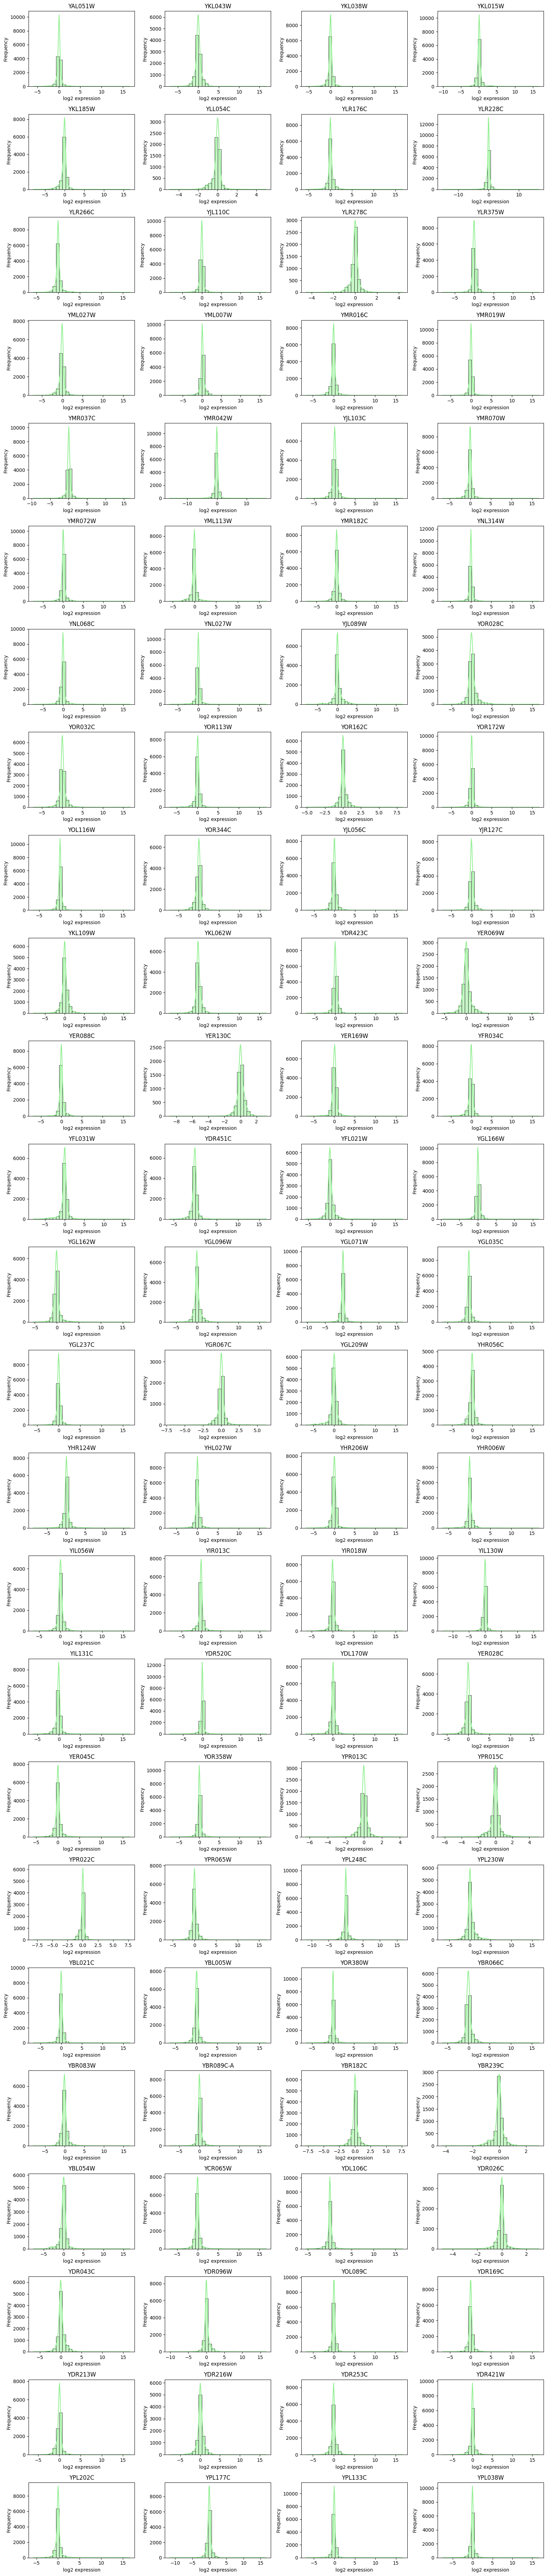

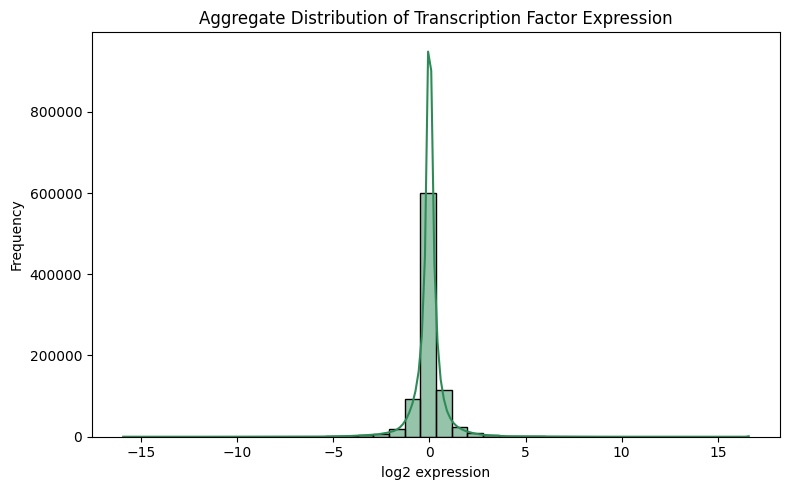

In [16]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

# Paths
data_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_master_matrix_dual.csv"
tf_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl"
output_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/hs_tf_study"
stats_output_path = os.path.join(output_dir, "stats_tf.txt")
histogram_path = os.path.join(output_dir, "tf_expression_histograms.svg")
aggregate_path = os.path.join(output_dir, "tf_expression_aggregate.svg")

# Make sure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load data
df = pd.read_csv(data_path, sep='\t', index_col=0)
with open(tf_pickle_path, "rb") as f:
    tf_genes = pickle.load(f)

tf_genes = [gene for gene in tf_genes if gene in df.index]

# Stats file handle
with open(stats_output_path, "w") as stats_file:

    # --- Individual stats and histograms ---
    num_genes = len(tf_genes)
    cols = 4
    rows = math.ceil(num_genes / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = axes.flatten()

    all_values = []

    for i, gene in enumerate(tf_genes):
        values = df.loc[gene].dropna()
        all_values.extend(values.tolist())

        mean = np.mean(values)
        median = np.median(values)
        std = np.std(values)

        stats_file.write(f"\nGene: {gene}\n")
        stats_file.write(f"  Mean: {mean:.4f}\n")
        stats_file.write(f"  Median: {median:.4f}\n")
        stats_file.write(f"  Std Dev: {std:.4f}\n")
        stats_file.write(f"  Min: {np.min(values):.4f}\n")
        stats_file.write(f"  Max: {np.max(values):.4f}\n")
        stats_file.write(f"  Non-NaN values: {len(values)}\n")

        sns.histplot(values, bins=30, kde=True, ax=axes[i], color='lightgreen')
        axes[i].set_title(gene)
        axes[i].set_xlabel("log2 expression")
        axes[i].set_ylabel("Frequency")

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(histogram_path, format='svg', dpi=500)
    # plt.show()

    # --- Aggregate stats ---
    all_values = np.array(all_values)
    stats_file.write("\n=== Aggregate statistics for all transcription factors ===\n")
    stats_file.write(f"  Mean: {np.mean(all_values):.4f}\n")
    stats_file.write(f"  Median: {np.median(all_values):.4f}\n")
    stats_file.write(f"  Std Dev: {np.std(all_values):.4f}\n")
    stats_file.write(f"  Min: {np.min(all_values):.4f}\n")
    stats_file.write(f"  Max: {np.max(all_values):.4f}\n")
    stats_file.write(f"  Total values: {len(all_values)}\n")

# Aggregate histogram
plt.figure(figsize=(8, 5))
sns.histplot(all_values, bins=40, kde=True, color='seagreen')
plt.title("Aggregate Distribution of Transcription Factor Expression")
plt.xlabel("log2 expression")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(aggregate_path, format='svg')
# plt.show()

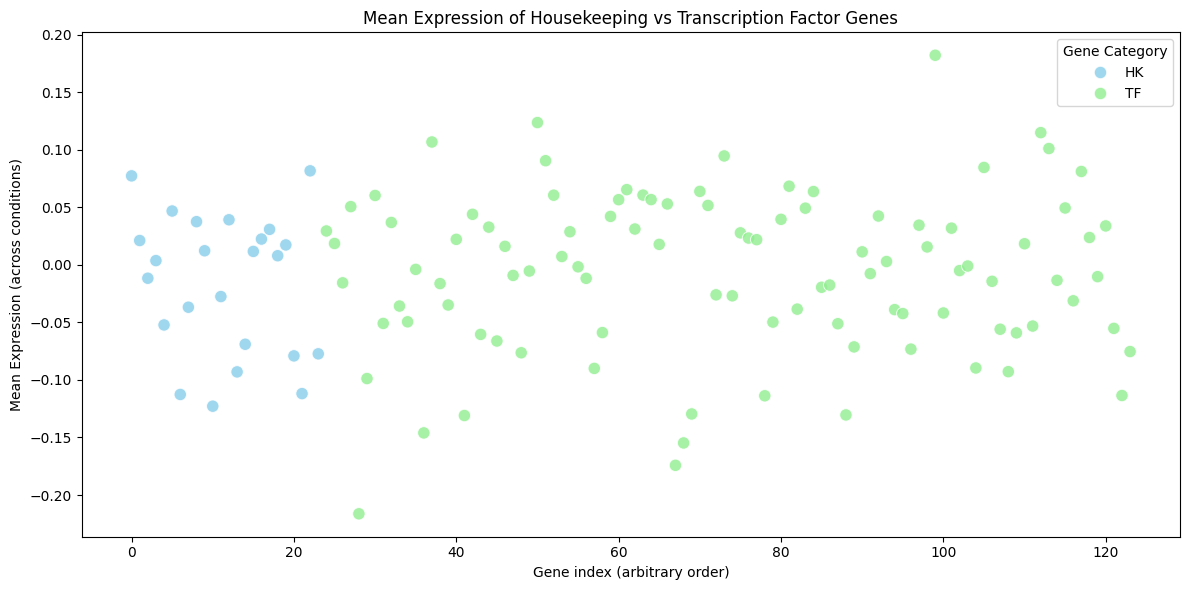

In [ ]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file paths
data_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_master_matrix_dual.csv"
hk_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl"
tf_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl"
output_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/hs_tf_study"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load expression data. The DataFrame should have genes as rows and conditions as columns.
df = pd.read_csv(data_path, sep='\t', index_col=0)

# Load gene lists
with open(hk_pickle_path, "rb") as f:
    housekeeping_genes = pickle.load(f)
with open(tf_pickle_path, "rb") as f:
    tf_genes = pickle.load(f)

# Filter lists to include only genes present in the dataset
housekeeping_genes = [gene for gene in housekeeping_genes if gene in df.index]
tf_genes = [gene for gene in tf_genes if gene in df.index]

# Compute mean expression for each gene across all conditions
hk_means = df.loc[housekeeping_genes].mean(axis=1)
tf_means = df.loc[tf_genes].mean(axis=1)

# Create DataFrames for each group with three columns: gene, mean_expr, and category
hk_df = pd.DataFrame({'gene': hk_means.index, 'mean_expr': hk_means.values, 'category': 'HK'})
tf_df = pd.DataFrame({'gene': tf_means.index, 'mean_expr': tf_means.values, 'category': 'TF'})

# Concatenate into a single DataFrame for plotting
plot_df = pd.concat([hk_df, tf_df], axis=0).reset_index(drop=True)

# For plotting purposes, create a simple numerical x-axis. This is just a helper.
plot_df['plot_index'] = range(len(plot_df))

# Create scatter plot with different colors for HK vs TF
plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_df, x='plot_index', y='mean_expr', hue='category',
                palette={'HK': 'skyblue', 'TF': 'lightgreen'}, s=80, alpha=0.8)

plt.xlabel("Gene index (arbitrary order)")
plt.ylabel("Mean Expression (across conditions)")
plt.title("Mean Expression of Housekeeping vs Transcription Factor Genes")
plt.legend(title="Gene Category")
plt.tight_layout()

# Save the plot as an SVG for high-quality zooming
#scatter_plot_path = os.path.join(output_dir, "mean_expression_scatter.svg")
# plt.savefig(scatter_plot_path, format='svg')
plt.show()

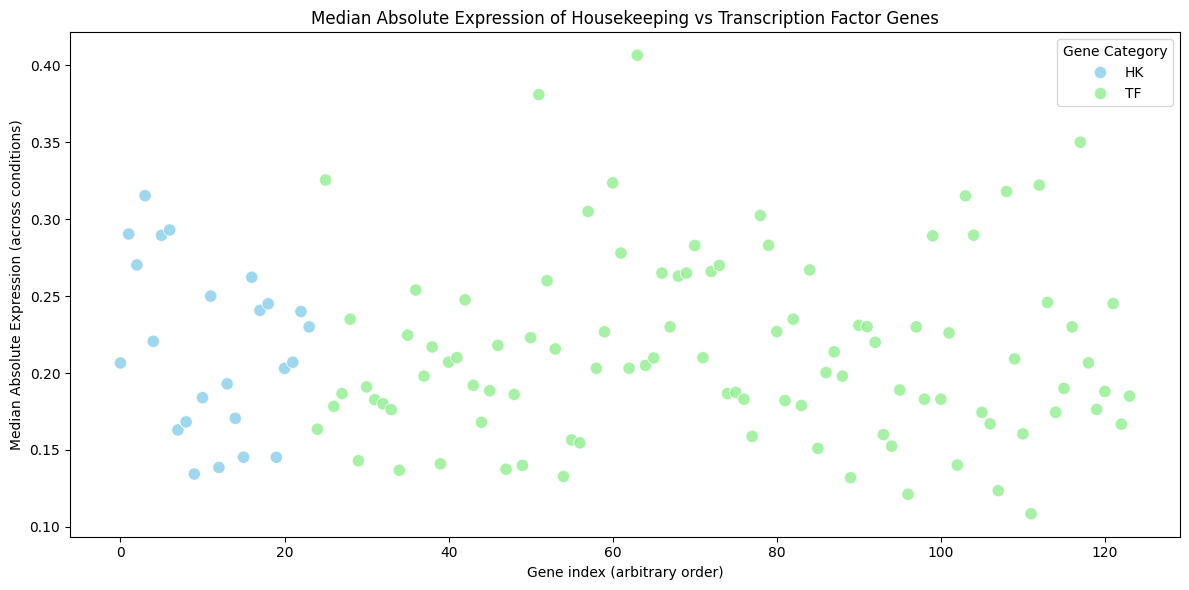

In [19]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file paths
data_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_master_matrix_dual.csv"
hk_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl"
tf_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl"
output_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/hs_tf_study"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load expression data. The DataFrame has genes as rows and conditions as columns.
df = pd.read_csv(data_path, sep='\t', index_col=0)

# Load gene lists
with open(hk_pickle_path, "rb") as f:
    housekeeping_genes = pickle.load(f)
with open(tf_pickle_path, "rb") as f:
    tf_genes = pickle.load(f)

# Filter lists to include only genes present in the dataset
housekeeping_genes = [gene for gene in housekeeping_genes if gene in df.index]
tf_genes = [gene for gene in tf_genes if gene in df.index]

# Compute the median of the absolute expression for each gene across all conditions.
# This means we take the absolute value of each expression value first.
hk_medians = df.loc[housekeeping_genes].abs().median(axis=1)
tf_medians = df.loc[tf_genes].abs().median(axis=1)

# Create DataFrames for each group with three columns: gene, median_expr, and category
hk_df = pd.DataFrame({'gene': hk_medians.index, 'median_expr': hk_medians.values, 'category': 'HK'})
tf_df = pd.DataFrame({'gene': tf_medians.index, 'median_expr': tf_medians.values, 'category': 'TF'})

# Concatenate into a single DataFrame for plotting
plot_df = pd.concat([hk_df, tf_df], axis=0).reset_index(drop=True)

# For plotting purposes, create an arbitrary numeric x-axis.
plot_df['plot_index'] = range(len(plot_df))

# Create scatter plot with different colors for HK vs TF, plotting the median absolute expression.
plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_df, x='plot_index', y='median_expr', hue='category',
                palette={'HK': 'skyblue', 'TF': 'lightgreen'}, s=80, alpha=0.8)

plt.xlabel("Gene index (arbitrary order)")
plt.ylabel("Median Absolute Expression (across conditions)")
plt.title("Median Absolute Expression of Housekeeping vs Transcription Factor Genes")
plt.legend(title="Gene Category")
plt.tight_layout()

# Save the plot as an SVG for high-quality zooming
scatter_plot_path = os.path.join(output_dir, "median_abs_expression_scatter.svg")
plt.savefig(scatter_plot_path, format='svg')
plt.show()


/tmp/ipykernel_2740790/1902394029.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='category', y=plot_data.columns[0], palette={'HK': 'skyblue', 'TF': 'lightgreen'})


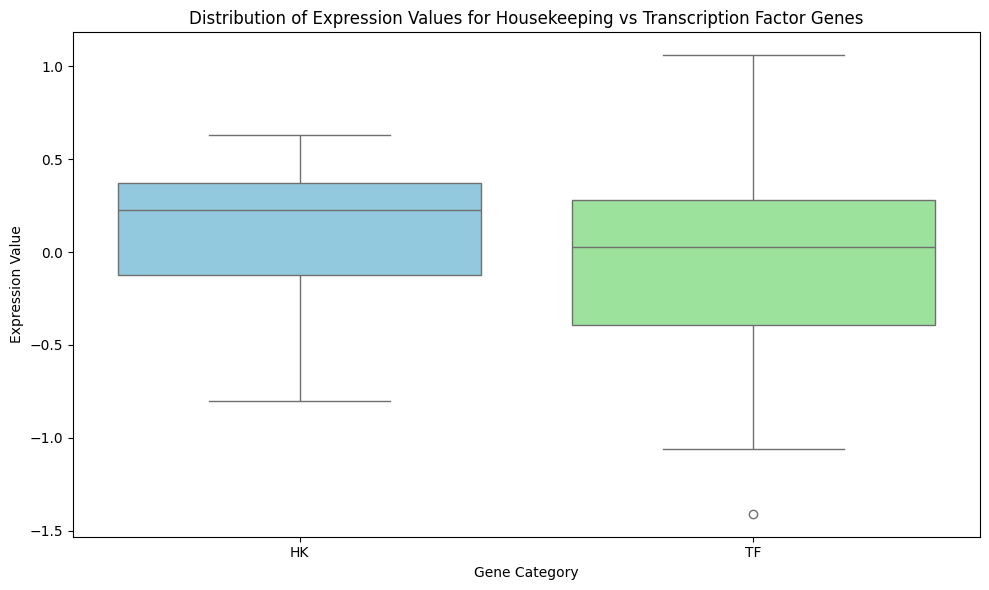

In [22]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Define file paths
pcl_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/dual_channel_pcls_modified/Yun_2000_PMID_10744769_2010.Yun00.flt.knn.avg.pcl"
hk_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl"
tf_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl"

# Load gene lists
with open(hk_pickle_path, "rb") as f:
    housekeeping_genes = pickle.load(f)
with open(tf_pickle_path, "rb") as f:
    tf_genes = pickle.load(f)

# Load the PCL file
df = pd.read_csv(pcl_path, sep='\t', index_col=0)

# Filter lists to include only genes present in the dataset
housekeeping_genes = [gene for gene in housekeeping_genes if gene in df.index]
tf_genes = [gene for gene in tf_genes if gene in df.index]

# Extract expression data for HK and TF genes
hk_data = df.loc[housekeeping_genes]
tf_data = df.loc[tf_genes]

# Create a DataFrame for plotting
plot_data = pd.concat([hk_data, tf_data], axis=0)
plot_data['category'] = ['HK'] * len(hk_data) + ['TF'] * len(tf_data)

# Plot side-by-side boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x='category', y=plot_data.columns[0], palette={'HK': 'skyblue', 'TF': 'lightgreen'})
plt.title('Distribution of Expression Values for Housekeeping vs Transcription Factor Genes')
plt.xlabel('Gene Category')
plt.ylabel('Expression Value')
plt.tight_layout()

# Show the plot
plt.show()


Housekeeping genes CV statistics:
count     24.000000
mean      46.020951
std       68.462459
min        6.518782
25%       11.069244
50%       20.867900
75%       45.924251
max      327.466379
dtype: float64

Transcription factors CV statistics:
count    100.000000
mean      44.224209
std      101.524622
min        4.408211
25%       10.761040
50%       18.122305
75%       34.512410
max      853.214836
dtype: float64


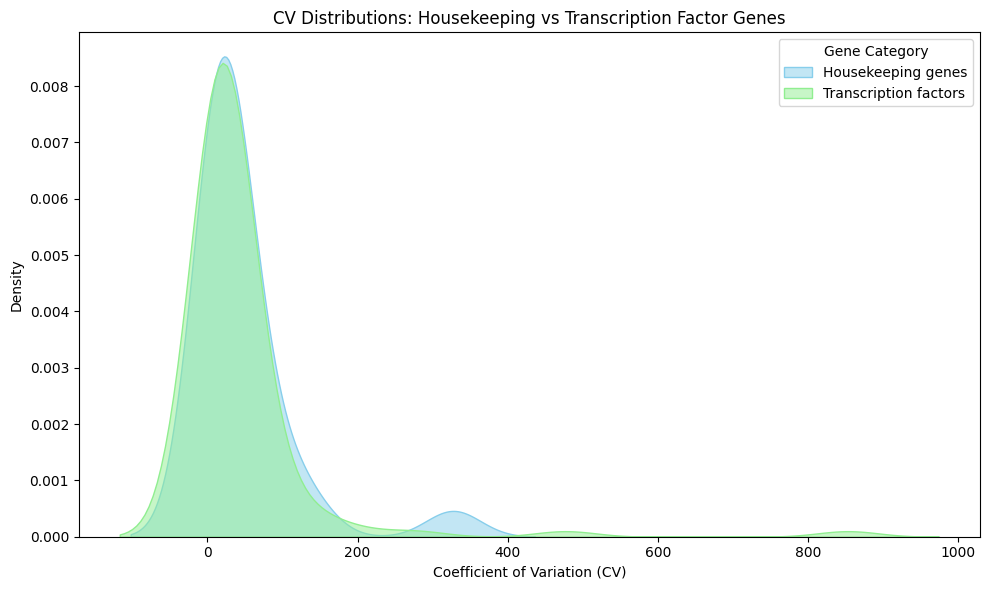

In [ ]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define file paths
data_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_master_matrix_dual.csv"
hk_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl"
tf_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl"
output_dir = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/hs_tf_study"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load expression data.
# Genes are assumed to be in the rows and conditions in the columns.
df = pd.read_csv(data_path, sep='\t', index_col=0)

# Load gene lists
with open(hk_pickle_path, "rb") as f:
    housekeeping_genes = pickle.load(f)
with open(tf_pickle_path, "rb") as f:
    tf_genes = pickle.load(f)

# Filter lists to include only genes present in the dataset
housekeeping_genes = [gene for gene in housekeeping_genes if gene in df.index]
tf_genes = [gene for gene in tf_genes if gene in df.index]

# Define a function to compute the coefficient of variation (CV) for a gene
# We use the absolute value of the mean to avoid issues if the mean is negative.
def compute_cv(values):
    mean_val = values.mean()
    # Avoid division by zero: if mean is 0, return NaN.
    if mean_val == 0:
        return np.nan
    return values.std() / abs(mean_val)

# Compute CVs for all genes in each list.
hk_cvs = df.loc[housekeeping_genes].apply(compute_cv, axis=1)
tf_cvs = df.loc[tf_genes].apply(compute_cv, axis=1)

# Drop any genes with NaN CV (for instance if mean was 0)
hk_cvs = hk_cvs.dropna()
tf_cvs = tf_cvs.dropna()

# Print some summary statistics for the CV distributions
print("Housekeeping genes CV statistics:")
print(hk_cvs.describe())
print("\nTranscription factors CV statistics:")
print(tf_cvs.describe())

# Plot the density curves (using seaborn.kdeplot) for comparison.
plt.figure(figsize=(10, 6))
sns.kdeplot(hk_cvs, label='Housekeeping genes', color='skyblue', fill=True, alpha=0.5)
sns.kdeplot(tf_cvs, label='Transcription factors', color='lightgreen', fill=True, alpha=0.5)
plt.xlabel("Coefficient of Variation (CV)")
plt.ylabel("Density")
plt.title("CV Distributions: Housekeeping vs Transcription Factor Genes")
plt.legend(title="Gene Category")
plt.tight_layout()

# Save the plot as an SVG file for high-quality zooming
density_plot_path = os.path.join(output_dir, "cv_density_comparison.svg")
plt.savefig(density_plot_path, format='svg')
plt.show()

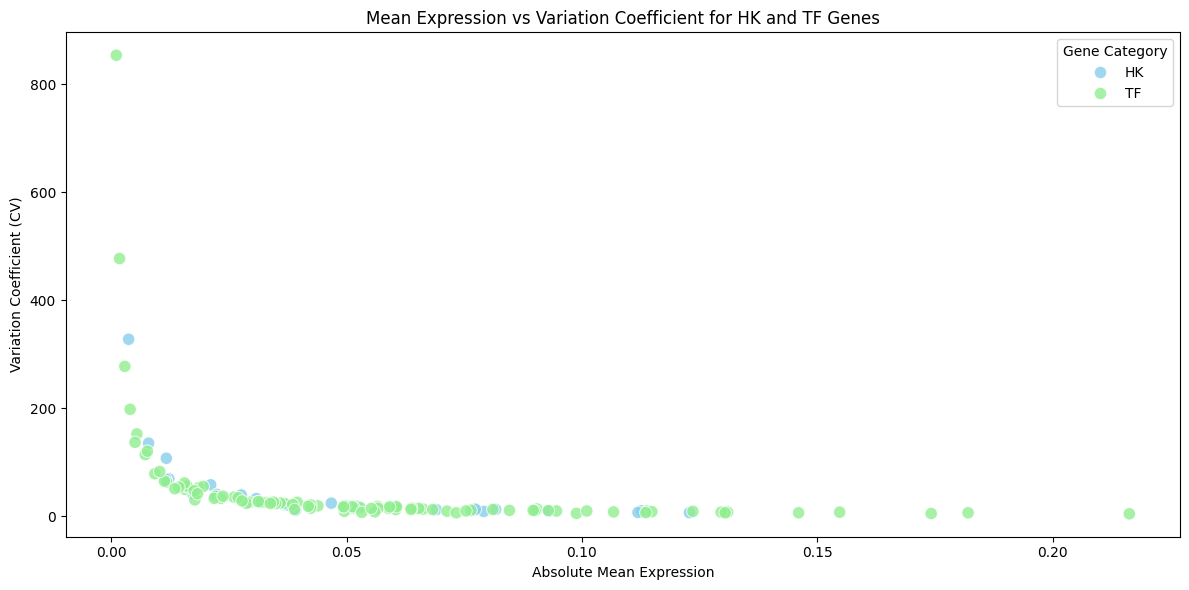

In [24]:
import pandas as pd
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define file paths
data_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/output/yeast_master_matrix_dual.csv"
hk_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/hk_genes.pkl"
tf_pickle_path = "/home/logs/jtorresb/yeastformer/yeast/yeast_data/genes_info/tf_genes.pkl"

# Load expression data
df = pd.read_csv(data_path, sep='\t', index_col=0)

# Load gene lists
with open(hk_pickle_path, "rb") as f:
    housekeeping_genes = pickle.load(f)
with open(tf_pickle_path, "rb") as f:
    tf_genes = pickle.load(f)

# Filter lists to include only genes present in the dataset
housekeeping_genes = [gene for gene in housekeeping_genes if gene in df.index]
tf_genes = [gene for gene in tf_genes if gene in df.index]

# Calculate the absolute mean and variation coefficient (CV) for each gene
def calculate_cv(dataframe, genes):
    means = dataframe.loc[genes].mean(axis=1).abs()  # Absolute mean
    stds = dataframe.loc[genes].std(axis=1)
    cv = stds / means  # Coefficient of variation (CV)
    return means, cv

# Compute mean and CV for HK and TF genes
hk_means, hk_cv = calculate_cv(df, housekeeping_genes)
tf_means, tf_cv = calculate_cv(df, tf_genes)

# Create DataFrames for each group with columns: gene, abs_mean, cv, and category
hk_df = pd.DataFrame({'gene': housekeeping_genes, 'abs_mean': hk_means, 'cv': hk_cv, 'category': 'HK'})
tf_df = pd.DataFrame({'gene': tf_genes, 'abs_mean': tf_means, 'cv': tf_cv, 'category': 'TF'})

# Concatenate into a single DataFrame for plotting
plot_df = pd.concat([hk_df, tf_df], axis=0).reset_index(drop=True)

# Create scatter plot with different colors for HK vs TF
plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_df, x='abs_mean', y='cv', hue='category', palette={'HK': 'skyblue', 'TF': 'lightgreen'}, s=80, alpha=0.8)

plt.xlabel("Absolute Mean Expression")
plt.ylabel("Variation Coefficient (CV)")
plt.title("Mean Expression vs Variation Coefficient for HK and TF Genes")
plt.legend(title="Gene Category")
plt.tight_layout()

# Show the plot
plt.show()
